<a href="https://colab.research.google.com/github/yrhutu21/Data_Science_MIniProjects/blob/main/Task8_Customer_Preference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Dataset .csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
#Handling of multiple cuisines
# Split cuisines into separate rows
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

df_cuisine = df.assign(Cuisines=df['Cuisines'].str.split(',')).explode('Cuisines')

# Remove extra spaces
df_cuisine['Cuisines'] = df_cuisine['Cuisines'].str.strip()

df_cuisine.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,French,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,Desserts,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,Seafood,...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270



Cuisine vs Average Rating

In [3]:
cuisine_rating = df_cuisine.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
print(cuisine_rating)

Cuisines
Sunda         4.900000
B�_rek        4.700000
Taiwanese     4.650000
Ramen         4.500000
Dim Sum       4.466667
Hawaiian      4.412500
D�_ner        4.400000
Bubble Tea    4.400000
Curry         4.400000
Kebab         4.380000
Name: Aggregate rating, dtype: float64


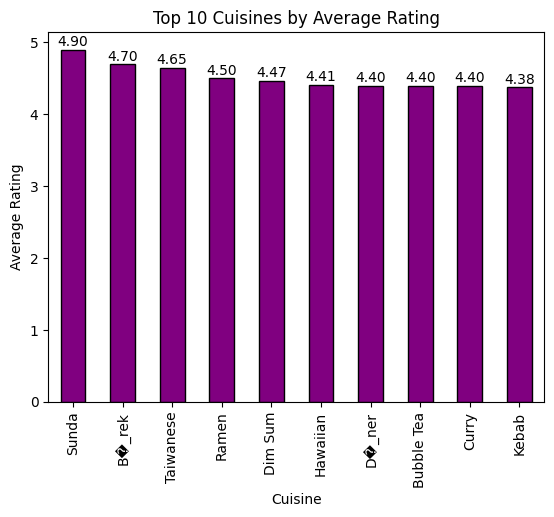

In [5]:
#Visual represenattion of Cuisine vs Average Rating

ax = cuisine_rating.plot(
    kind='bar',
    color='purple',
    edgecolor='black'
)

plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")

for i, v in enumerate(cuisine_rating):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center')

#plt.xticks(rotation=45)
plt.show()


Most Popular Cuisines

In [6]:
cuisine_votes = df_cuisine.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(10)
print(cuisine_votes)

Cuisines
North Indian    595981
Chinese         364351
Italian         329265
Continental     288255
Fast Food       184058
American        183117
Cafe            177568
Mughlai         151946
Desserts        105889
Asian           104303
Name: Votes, dtype: int64


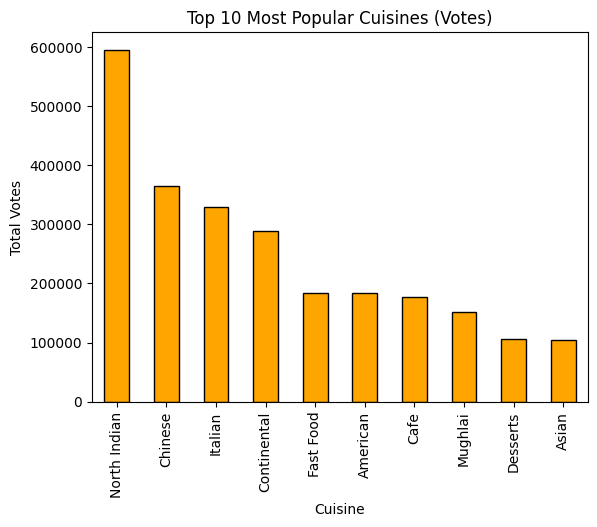

In [8]:
#Visual represntation of most popular cuisines

ax = cuisine_votes.plot(
    kind='bar',
    color='orange',
    edgecolor='black'
)

plt.title("Top 10 Most Popular Cuisines (Votes)")
plt.xlabel("Cuisine")
plt.ylabel("Total Votes")

#plt.xticks(rotation=45)
plt.show()

Comparison of Rating vs Popularity

In [9]:
comparison = pd.DataFrame({
    'Average Rating': cuisine_rating,
    'Total Votes': cuisine_votes
})

print(comparison)

              Average Rating  Total Votes
Cuisines                                 
American                 NaN     183117.0
Asian                    NaN     104303.0
Bubble Tea          4.400000          NaN
B�_rek              4.700000          NaN
Cafe                     NaN     177568.0
Chinese                  NaN     364351.0
Continental              NaN     288255.0
Curry               4.400000          NaN
Desserts                 NaN     105889.0
Dim Sum             4.466667          NaN
D�_ner              4.400000          NaN
Fast Food                NaN     184058.0
Hawaiian            4.412500          NaN
Italian                  NaN     329265.0
Kebab               4.380000          NaN
Mughlai                  NaN     151946.0
North Indian             NaN     595981.0
Ramen               4.500000          NaN
Sunda               4.900000          NaN
Taiwanese           4.650000          NaN
